In [1]:

import numpy as np
import math
import serial
import struct
import time
from enum import Enum
from matplotlib import pyplot as plt
import cv2 as cv
from random import sample

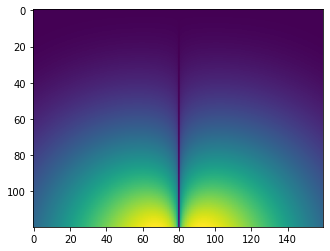

In [61]:
def scaled_2d_matrix(height, width, degree1, degree2, degree3):
	zs = np.zeros((height, width), dtype = float)
	max_v_len = math.sqrt((height ** 2 + (width/2) ** 2))
	with np.nditer(zs, op_flags=['readwrite'], flags=['multi_index']) as it:
		for a in it:
			j, i = it.multi_index
			i -= width/2
			j = height - j
			v_len = math.sqrt((j ** 2 + i ** 2))
			len_scale = (1 - (v_len/max_v_len)) ** degree1
			y_scale = (1 - (j/height)) ** degree2
			x_scale = (2 * abs(i)/width) ** degree3

			a[...] = len_scale * y_scale * x_scale
			# a[...] = (1 - (j/height)) ** degree
	return zs/np.max(zs)
scale = scaled_2d_matrix(120, 160, 2, 0.7, 0.2)
plt.imshow(scale)
plt.show()

In [2]:
%matplotlib inline

In [20]:
src = cv.imread("./original.png")

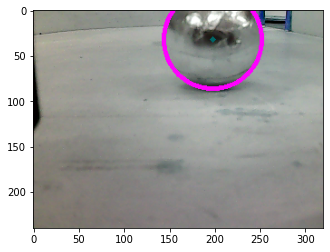

In [22]:

gray = cv.cvtColor(src, cv.COLOR_BGR2GRAY)
gray = cv.medianBlur(gray, 5)
rows = gray.shape[0]
circles = cv.HoughCircles(gray, cv.HOUGH_GRADIENT, 1, 10,
                            param1=200, param2=20, minRadius=22)


if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        center = (i[0], i[1])
        # circle center
        cv.circle(src, center, 1, (0, 100, 100), 3)
        # circle outline
        radius = i[2]
        cv.circle(src, center, radius, (255, 0, 255), 3)


plt.imshow(src)
plt.show()
# cv.imshow("edge", edges)

In [8]:
edges

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [9]:
thres_dist = 10
volting = 50
max_iter = 50

In [12]:
def get_circle(x: tuple, y: tuple, z: tuple):
	x, y, z = complex(x[0], x[1]), complex(y[0], y[1]), complex(z[0], z[1])
	w = z-x
	w /= y-x
	c = (x-y)*(w-abs(w)**2)/2j/w.imag-x

	return c.real, c.imag, abs(c+x)

def get_rand_circle(edges, h, w, max_r):
	x, y, r = 0, 0, 0
	non_zero = list(zip(*np.nonzero(edges)))
	while True:
		points = sample(non_zero, 3)
		points = tuple(points)
		print("hello")
		try:
			x, y, r = get_circle(*points)
			if (x >= 0 and x <= w) and (y >= 0 and y <= h) and r <= max_r:
				break
		except:
			pass
	return x, y, r

def in_circle(point, xc, yc, r) -> bool:
	return ((point[0] - xc) ** 2 + (point[1] - yc) ** 2) <= r ** 2

def get_inlier_points(edge, xc, yc, r):
	points = []
	non_zero = zip(*np.nonzero(edge))
	for y, x in non_zero:
		if in_circle((x, y), xc, yc, r + thres_dist) and not in_circle((x, y), xc, yc, r - thres_dist):
			points.append((x, y))
	# with np.nditer(edge, op_flags=['readwrite'], flags=['multi_index']) as it:
	# 	for a in it:
	# 		if a != 0:
	# 			y, x = it.multi_index
	# 			if in_circle((x, y), xc, yc, r + thres_dist) and not in_circle((x, y), xc, yc, r - thres_dist):
	# 				points.append((x, y))
	return points

In [14]:
edge_copy = edges
inlier_counter = []
for i in range(1, max_iter):
	xc, yc, r = get_rand_circle(edge_copy, *edge_copy.shape, 100)
	inliers = get_inlier_points(edge_copy, xc, yc, r)
	# print(inliers)
	inlier_counter.append({
		"x": xc,
		"y": yc,
		"r": r,
		"len": len(inliers)
	})
c_test = max(inlier_counter, key = lambda x: x["len"])
	

hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
hell

KeyboardInterrupt: 

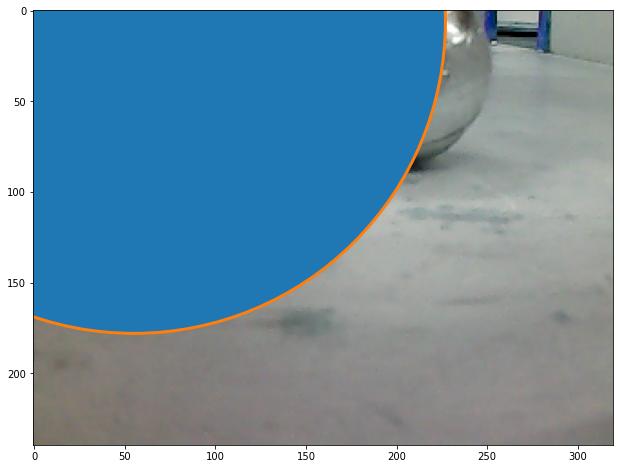

In [116]:
# x, y, r = get_rand_circle(edge_copy)
# edge_copy = cv.circle(edge_copy, (int(x),int(y)), int(r), 255, 2)
# print(x, y, r)
c = plt.Circle((int(c_test["x"]), int(c_test["y"])), int(c_test["r"]), fill=True, lw=3, ec='C1')
plt.gca().add_patch(c)
plt.gcf().set_size_inches((12, 8))
plt.imshow(test_frame)
plt.show()

In [19]:
crop_h = 30
b_crop_h = 0
gs_crop_h = 100
b_gs_crop_h = 20

b_w_thresh = 70 #
#* the region of image to consider whether robot is "done" with the particular green square
gs_lt_roi = 50

epsilon = 30 * math.pi/180
delta = 10 * math.pi/180

d_green_square_min = 1000000 #TODO: Determine Actual Min, this is just a guess (I was very incorrect)
s_green_square_min = 5000

right_turn_rotation = 0.75
min_area = 200

boundaries = {
	"red": ((0,0,0), (0,0,0)),
	"green": ((50,60,60), (80,255,255)),
	"blue": ((94, 50, 50), (125, 255, 255))
}

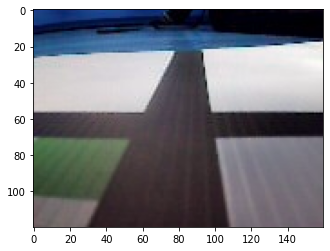

In [7]:
frame_org = cv.imread("WIN_20220410_08_46_15_Pro.jpg")
plt.imshow(frame_org)
plt.show()

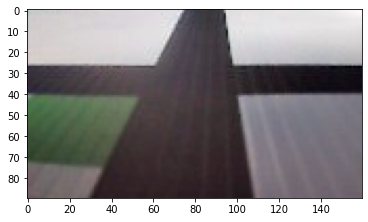

In [9]:
frame = frame_org[crop_h:(frame_org.shape[0] - b_crop_h), :]
plt.imshow(frame)
plt.show()

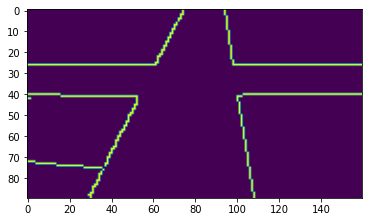

In [22]:
edges = cv.Canny(frame,100, 200)
plt.imshow(edges)
plt.show()

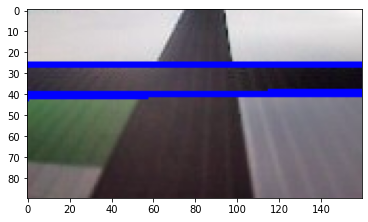

In [31]:
def h_line_filter(line):
	rho, theta = line[0]
	if theta <= math.pi/2 + epsilon and theta >= math.pi/2 - epsilon:
		return True
	else:
		return False
lines = cv.HoughLines(edges,1,np.pi/180,50)
lines = list(filter(h_line_filter, lines))
frame_c = frame.copy()
for line in lines:
    rho,theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv.line(frame_c,(x1,y1),(x2,y2),(0,0,255),2)
plt.imshow(frame_c)
plt.show()

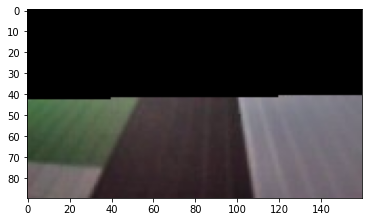

In [29]:
def h_line_filter(line):
	rho, theta = line[0]
	if theta <= math.pi/2 + epsilon and theta >= math.pi/2 - epsilon:
		return True
	else:
		return False

def y_value(line, x_value):
	rho, theta = line[0]
	return (rho - x_value*math.cos(theta))/(math.sin(theta))

width = frame.shape[1]
f_lines = list(filter(h_line_filter, lines))
if len(f_lines) > 0:
    y_intercepts = [int(y_value(line, 0)) for line in f_lines]
    width_intercepts = [int(y_value(line, width)) for line in f_lines]

    mask = np.ones(frame.shape[:2], dtype=np.uint8)
    useless_pixels = np.array([
        [0, 0], 
        [width, 0], 
        [width, max(width_intercepts)],
        [0, max(y_intercepts)]
    ])
    
    cv.fillPoly(mask, pts =[useless_pixels], color=0)

    # Above masks out the portion of the image above the line
    # Since we don't care about what happens above the black line

    roi = cv.bitwise_and(frame, frame, mask=mask)
    plt.imshow(roi)
    plt.show()

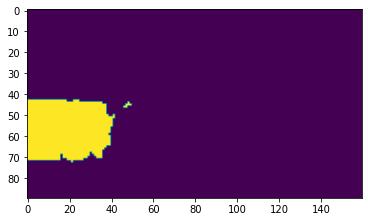

In [30]:
frame_hsv = cv.cvtColor(roi, cv.COLOR_BGR2HSV)
green = cv.inRange(frame_hsv, boundaries["green"][0], boundaries["green"][1])
plt.imshow(green)
plt.show()

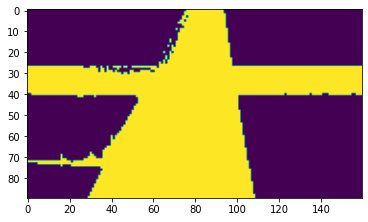

In [38]:
gray = cv.cvtColor(frame,cv.COLOR_BGR2GRAY)
cv.imwrite("gray.png", gray)
t, thresh = cv.threshold(gray, 90, 255 ,cv.THRESH_BINARY_INV)
not_green = cv.bitwise_not(green)
black = cv.bitwise_and(thresh, not_green)
plt.imshow(black)
plt.show()

In [ ]:
frame = frame_org[crop_h:(frame_org.shape[0] - b_crop_h), :]
gs_frame = frame_org[gs_crop_h:(frame_org.shape[0] - b_gs_crop_h), :]

gs_frame_gray = cv.cvtColor(gs_frame, cv.COLOR_BGR2GRAY)

gs_frame = cv.cvtColor(gs_frame, cv.COLOR_BGR2HSV)
green = cv.inRange(gs_frame, boundaries["green"][0], boundaries["green"][1])

edges = cv.Canny(gs_frame_gray,100, 200)
lines = cv.HoughLines(edges,1,np.pi/180,80)